In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import heapq
import seaborn as sns

from environment.environment import GraphWorldMFG_MultiGroup
from trainer.amid_trainer_graph import GraphEdgeMFG_Trainer
from solver.solver import solve_multigroup, GraphMFG_OMD_EdgeSolver_MultiGroup
from visualization.visualizationh import plot_heatmap, compute_exploitability_multigroup, plot_losses, plot_losses_line

In [2]:
import os
from pathlib import Path
import yaml
import numpy as np
import torch

# 1. Configuration Loader
def load_config(config_path="config.yaml"):
    """Load configuration safely from a YAML file relative to working directory."""
    notebook_dir = Path(os.getcwd())
    config_file = notebook_dir / config_path
    
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    return config

# 2. Graph Environment Factory Pattern
def create_graph_mfg_from_config(config):
    """Factory function initializing the Graph MFG environment directly from your config."""
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Target Device: {device}")

    trainer_cfg = config["trainer"]
    
    # Extract Graph Configuration
    graph_cfg = config["graph"]
    num_nodes = graph_cfg["num_nodes"]
    
    # CRITICAL: Extract the list of lists matrix and convert to a PyTorch Tensor
    raw_matrix = graph_cfg["adjacency_matrix"]
    adjacency_matrix = torch.tensor(raw_matrix, dtype=torch.float32, device=device)
    
    # Process Group Data (Sinks and Sources are flat integers here, not grid tuples)
    groups = []
    for g in config["groups"]:
        groups.append({
            "source": int(g["source"]),
            "sink": int(g["sink"]),
            "mass": float(g["mass"])
        })
    
    solver_cfg = config["solver"]
    waiting_time = solver_cfg.get("waiting_time", 0)
    # Instantiate the Graph World Environment
    # (Matches your 'GraphWorldMFG_MultiGroup' class structure)
    env = GraphWorldMFG_MultiGroup(
        num_nodes=num_nodes,
        groups=groups,
        adjacency_matrix=adjacency_matrix,
        H = solver_cfg.get("H", None),
        device=device
    )
    
    # Create solvers for each group
    
    
    solvers = [
        GraphMFG_OMD_EdgeSolver_MultiGroup(
            env=env,
            group_idx=k,
            eta=solver_cfg["eta"],
            tau=solver_cfg["tau"],
            T=solver_cfg["T"],
            alpha=solver_cfg["alpha"],
            H=solver_cfg.get("H", None)
        )
        for k in range(env.K)
    ]

    trainer = GraphEdgeMFG_Trainer(env, solvers, leader_lr=trainer_cfg["leader_lr"])
    
    return env, solvers, trainer, config

In [3]:
config = load_config("config_graph.yaml")

env, solvers, trainer, config = create_graph_mfg_from_config(config)

# Training loop
theta_leader = torch.zeros((env.N, env.N), device=env.device)  # Initialize leader's strategy
#theta_leader[1,2] = 5.0
#theta_leader[2,1] = 5.0

Target Device: cpu


c:\Uzh\thesis\msc_code\thesis\environment\environment.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.A = torch.tensor(adjacency_matrix, dtype=torch.float32, device=device)


In [4]:
node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history = solve_multigroup(env, solvers, T=50, W_max=15, theta_leader=theta_leader)

In [5]:
exploitability, V_best, V_pi = solvers[0].compute_exploitability(W_cong_history, W_max=15, theta_leader=theta_leader)
exploitability

0.014270782470703125

In [ ]:
edge_occ.sum(dim=0).sum(dim=-1)  # Total flow across all groups and time stepss

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 8.9225e-01, 1.0775e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 8.9225e-01, 1.0775e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 8.9225e-01, 1.0775e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 8.9225e-01, 1.0775e-01, 0.

In [31]:
final_flows

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000, 0.0000],
        [0.0833, 0.2500, 0.0833, 0.0000],
        [0.1111, 0.0608, 0.0833, 0.0239],
        [0.0480, 0.0742, 0.2703, 0.0512],
        [0.1148, 0.1269, 0.2747, 0.1031],
        [0.1339, 0.1361, 0.0423, 0.1758],
        [0.0595, 0.0706, 0.0454, 0.2877],
        [0.0386, 0.0646, 0.0444, 0.3899],
        [0.0363, 0.0400, 0.0701, 0.4568],
        [0.0367, 0.0424, 0.0531, 0.5010],
        [0.0318, 0.0361, 0.0548, 0.5533],
        [0.0303, 0.0346, 0.0742, 0.6154],
        [0.0363, 0.0401, 0.0599, 0.6731],
        [0.0333, 0.0376, 0.0379, 0.7166],
        [0.0252, 0.0295, 0.0313, 0.7480],
        [0.0203, 0.0236, 0.0281, 0.7725],
        [0.0172, 0.0198, 0.0250, 0.7951],
        [0.0149, 0.0171, 0.0221, 0.8153],
        [0.0131, 0.0150, 0.0224, 0.8352],
        [0.0124, 0.0141, 0.0224, 0.8556],
        [0.0122, 0.0137, 0.0193, 0

In [32]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(13.8666)

In [23]:
import numpy as np
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from PIL import Image
import io

# --- 1. Extract environment variables from your notebook execution ---
num_nodes = env.num_nodes
nodes = [str(i) for i in range(num_nodes)] # ['0', '1', '2', '3']

# Spatial coordinates for your 4-node MFG setup
node_coords = {
    '0': (0, 1),   # Source Node
    '1': (1, 1.5), # Intermediate Top
    '2': (1, 0.5), # Intermediate Bottom
    '3': (2, 1)    # Destination Node
}

# Pull physical roads defined in your environment's adjacency matrix
adjacency_matrix = env.A.cpu().numpy()
road_topology = []
for u_idx in range(num_nodes):
    for v_idx in range(num_nodes):
        if adjacency_matrix[u_idx, v_idx] > 0:
            road_topology.append((str(u_idx), str(v_idx)))

# Compute the composite edge flows (H, N, N) from the model outputs
# Simply sum/reduce over group/other dimensions to get shape (H, N, N)
edge_flows_tensor = edge_occ.sum(dim=0).sum(dim=-1)  # If this yields shape (H, N, N)
E_total_edges = edge_flows_tensor.detach().cpu().numpy()

num_steps = E_total_edges.shape[0]
timesteps = [f"Horizon {h}" for h in range(num_steps)]
max_flow_value = float(np.max(E_total_edges)) if np.max(E_total_edges) > 0 else 1.0

# --- 2. Initialize the Subplot Figure ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "1. Origin-Destination Heatmap",
        "2. Physical Road Network (Thickness=Volume)"
    ),
    horizontal_spacing=0.1
)

# --- 3. Base Traces (Horizon 0) ---
z_init = E_total_edges[0]
heatmap_base = go.Heatmap(
    z=z_init, x=nodes, y=nodes,
    colorscale="Reds", zmin=0, zmax=max_flow_value,
    text=np.round(z_init, 3), texttemplate="%{text}",
    colorbar=dict(title="Flow Rate", len=0.45, y=0.5, x=0.45),
)
fig.add_trace(heatmap_base, row=1, col=1)

node_x = [node_coords[n][0] for n in nodes]
node_y = [node_coords[n][1] for n in nodes]
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=nodes, textposition="top center",
    marker=dict(size=28, color='#333333', line=dict(width=2, color='white'))
)
fig.add_trace(node_trace, row=1, col=2)

for u, v in road_topology:
    x0, y0 = node_coords[u]
    x1, y1 = node_coords[v]
    u_idx, v_idx = int(u), int(v)
    flow = E_total_edges[0, u_idx, v_idx]
    
    width = 1.5 + (flow / max_flow_value) * 12
    color = '#D32F2F' if flow > (max_flow_value * 0.4) else '#E0E0E0'
    
    edge_trace = go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
    )
    fig.add_trace(edge_trace, row=1, col=2)

# --- 4. Populate Frames ---
frames = []
for t in range(num_steps):
    frame_data = []
    
    z_frame = E_total_edges[t]
    frame_data.append(go.Heatmap(
        z=z_frame, text=np.round(z_frame, 3), texttemplate="%{text}"
    ))
    
    frame_data.append(node_trace)
    
    for u, v in road_topology:
        u_idx, v_idx = int(u), int(v)
        flow = E_total_edges[t, u_idx, v_idx]
        width = 1.5 + (flow / max_flow_value) * 12
        color = '#D32F2F' if flow > (max_flow_value * 0.08) else '#E0E0E0'
        
        frame_data.append(go.Scatter(
            line=dict(width=width, color=color),
            text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
        ))
        
    frames.append(go.Frame(data=frame_data, name=timesteps[t]))
    
fig.frames = frames

# --- 5. Add Layout & Slider Configurations ---
sliders = [{
    "active": 0,
    "currentvalue": {"prefix": "Time Step: ", "font": {"size": 14}},
    "pad": {"t": 50},
    "steps": [{
        "args": [[f_name], {"frame": {"duration": 600, "redraw": True}, "mode": "immediate"}],
        "label": f_name, "method": "animate"
    } for f_name in timesteps]
}]

fig.update_layout(
    title="Synchronized Mean Field Game Network Flow Dashboard",
    height=650,
    showlegend=False,
    xaxis2=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.5, 2.5]),
    yaxis2=dict(showgrid=False, zeroline=False, showticklabels=False, range=[0.0, 2.0]),
    xaxis=dict(tickangle=0),
    updatemenus=[{
        "type": "buttons", "direction": "left", "pad": {"r": 10, "t": 87}, "showactive": False,
        "x": 0.1, "y": 0, "xanchor": "right", "yanchor": "top",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 800, "redraw": True}}]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}
        ]
    }],
    sliders=sliders
)

# Display interactive dashboard in the notebook
fig.show()
fig.write_html("traffic_flow.html")

In [9]:
node_mass, edge_occ, final_flows, policy_sim, W_cong_history = env.simulate_forward_with_policy(zeta_history[49], W_max=15, theta_leader=theta_leader)

In [10]:
final_flows

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 3.6529e-01, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 6.4878e-02, 0.0000e+00, 0.0000e+00],
        [9.7558e-06, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.8441e-06, 0.0000e+00, 2.8492e-01, 0.0000e+00],
        [0.0000e+00, 5.2447e-06, 2.8492e-01, 0.0000e+00],
        [1.5599e-13, 1.4459e-06, 0.0000e+00, 0.0000e+00],
        [3.4519e-10, 4.8369e-11, 0.0000e+00, 1.6394e-01],
        [7.3556e-11, 8.1847e-14, 7.3552e-17, 4.6756e-01],
        [2.5760e-15, 1.7515e-10, 4.2974e-17, 7.2560e-01],
        [4.6343e-18, 3.7333e-11, 2.2555e-06, 9.9999e-01],
        [1.0248e-14, 1.3156e-15, 2.9546e-06, 9.9999e-01],
        [2.2139e-15, 2.3424e-18, 6.9911e-07, 9.9999e-01],
        [8.0815e-20, 5.1408e-15, 3.7083e-14, 1.0000e+00],
        [2.013

In [24]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(10.9889)

In [10]:
loss = 0
for i in range(env.H):
    cost = final_flows[i, 3] - 1
    loss = loss + cost
loss

tensor(-10.9889)

In [13]:
config = load_config("config_graph.yaml")

env, solvers, trainer, config = create_graph_mfg_from_config(config)

# Training loop
theta_leader = torch.zeros((env.N, env.N), device=env.device)  # Initialize leader's strategy
#theta_leader[1,2] = 5.0
#theta_leader[2,1] = 5.0

node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history = solve_multigroup(env, solvers, T=1, W_max=15, theta_leader=theta_leader)

Target Device: cpu


In [14]:
edge_occ.sum(dim=0).sum(dim=-1)  # Total flow across all groups and time steps

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 5.0000e-01, 5.0000e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 5.0000e-01, 5.0000e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 2.5000e-01, 5.0000e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 0.0000e+00, 5.0000e-01, 0.

In [15]:
print("Starting Leader Infrastructure Optimization...")
print("-" * 50)
flows_previous = final_flows.detach()  # Detach to avoid backprop through the entire history
W_cong_history = W_cong_history.detach()  # Detach to avoid backprop
losses = []

epochs = 25
for epoch in range(1, epochs + 1):
    
    # Execute one optimization step
    social_loss, flows_new, W_cong_history_new, theta_leader_new = trainer.train_step(flows_previous, W_cong_history, epoch)
    
    # Pass the newly generated flows as the historical footprint for the next epoch
    flows_previous = flows_new.detach() 
    W_cong_history = W_cong_history_new.detach()
    theta_leader = theta_leader_new.detach()

    # Optional: Recompute or update W_cong_history based on flows_new if required, 
    # otherwise it continues to adapt based on the internal solve_multigroup loop.
    
    if epoch % 1 == 0:
        print(f"Epoch {epoch:02d}/{epochs} | Social Loss (Travel Time): {social_loss:.4f}")
    
    losses.append(social_loss)

print("-" * 50)
print("Training Complete!") 

Starting Leader Infrastructure Optimization...
--------------------------------------------------
Iteration 1: Leader theta_leader =
tensor([[2.5090, 2.4793, 2.5313, 2.4662],
        [2.4790, 2.3733, 2.5274, 2.3820],
        [2.5817, 2.6487, 2.4702, 2.6013],
        [2.4317, 2.5510, 2.6003, 2.5201]])
Exploitability: 0.9000434875488281
Epoch 01/25 | Social Loss (Travel Time): 14.9748
Iteration 2: Leader theta_leader =
tensor([[2.4303, 1.2908, 3.0452, 2.5003],
        [2.2529, 1.6253, 3.1890, 1.9145],
        [2.0048, 3.2965, 2.4900, 1.2857],
        [2.0007, 2.9205, 3.1194, 2.6356]])
Exploitability: 0.27480316162109375
Epoch 02/25 | Social Loss (Travel Time): 13.7692
Iteration 3: Leader theta_leader =
tensor([[2.7946e+00, 5.8453e-03, 3.3040e-02, 1.8913e+00],
        [3.7687e+00, 3.7917e-02, 4.8005e+00, 1.2931e-01],
        [5.3180e-01, 4.9302e+00, 3.2686e+00, 5.6260e-06],
        [4.7314e-01, 4.8050e+00, 4.4572e+00, 4.4277e+00]])
Exploitability: 0.4850587844848633
Epoch 03/25 | Social L

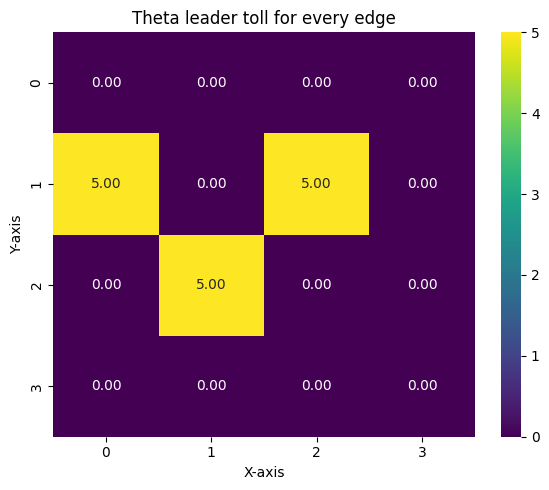

In [ ]:
plot_heatmap(theta_leader * env.A, title = "Theta leader toll for every edge")

In [35]:
theta_leader * env.A

tensor([[0., 0., 0., 0.],
        [5., 0., 5., 0.],
        [0., 5., 0., 0.],
        [0., 0., 0., 0.]])

In [36]:
node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history = solve_multigroup(env, solvers, T=50, W_max=15, theta_leader=theta_leader)

In [ ]:
edge_occ.sum()

In [44]:
edge_occ.sum(dim=0).sum(dim=-1)  # Total flow across all groups and time steps

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 4.3018e-01, 5.6982e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 4.3018e-01, 5.6982e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 6.4921e-02, 5.6982e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 0.0000e+00, 5.6982e-01, 0.

In [37]:
final_flows

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 3.6526e-01, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 6.4921e-02, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 2.8491e-01, 0.0000e+00],
        [8.1556e-24, 0.0000e+00, 2.8491e-01, 0.0000e+00],
        [1.1867e-18, 4.0944e-24, 0.0000e+00, 1.6395e-01],
        [2.8026e-45, 5.9376e-19, 7.0900e-27, 4.6754e-01],
        [0.0000e+00, 1.7628e-36, 8.2746e-27, 7.2563e-01],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 2.0306e-24, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 2.9649e-19, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 2.9649e-19, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00],
        [0.000

In [38]:
exploitability, V_best, V_pi = solvers[0].compute_exploitability(W_cong_history, W_max=15, theta_leader=theta_leader)
exploitability

0.00606536865234375

In [39]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(9.6429)

In [40]:
losses

[tensor(15.0303),
 tensor(12.7114),
 tensor(9.6430),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429),
 tensor(9.6429)]

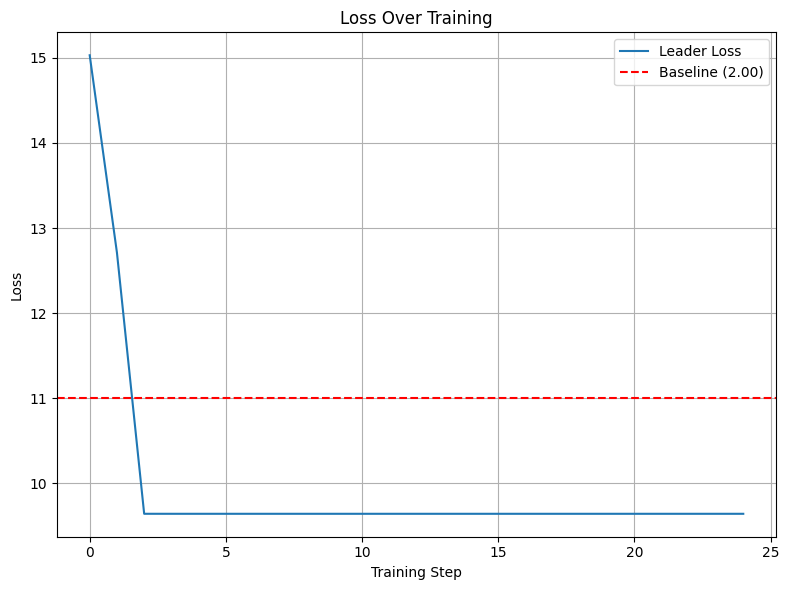

In [41]:
import torch
# Convert the tensors to plain floats inside the dictionary
loss_dict = {
    "Leader Loss": [loss.item() for loss in losses]
}

# Now you can pass it safely to your plotting function
plot_losses_line(loss_dict, yline=11)

In [42]:
edge_occ.shape

torch.Size([1, 25, 4, 4, 16])

In [43]:
import numpy as np
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from PIL import Image
import io

# --- 1. Extract environment variables from your notebook execution ---
num_nodes = env.num_nodes
nodes = [str(i) for i in range(num_nodes)] # ['0', '1', '2', '3']

# Spatial coordinates for your 4-node MFG setup
node_coords = {
    '0': (0, 1),   # Source Node
    '1': (1, 1.5), # Intermediate Top
    '2': (1, 0.5), # Intermediate Bottom
    '3': (2, 1)    # Destination Node
}

# Pull physical roads defined in your environment's adjacency matrix
adjacency_matrix = env.A.cpu().numpy()
road_topology = []
for u_idx in range(num_nodes):
    for v_idx in range(num_nodes):
        if adjacency_matrix[u_idx, v_idx] > 0:
            road_topology.append((str(u_idx), str(v_idx)))

# Compute the composite edge flows (H, N, N) from the model outputs
# Simply sum/reduce over group/other dimensions to get shape (H, N, N)
edge_flows_tensor = edge_occ.sum(dim=0).sum(dim=-1)  # If this yields shape (H, N, N)
E_total_edges = edge_flows_tensor.detach().cpu().numpy()

num_steps = E_total_edges.shape[0]
timesteps = [f"Horizon {h}" for h in range(num_steps)]
max_flow_value = float(np.max(E_total_edges)) if np.max(E_total_edges) > 0 else 1.0

# --- 2. Initialize the Subplot Figure ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "1. Origin-Destination Heatmap",
        "2. Physical Road Network (Thickness=Volume)"
    ),
    horizontal_spacing=0.1
)

# --- 3. Base Traces (Horizon 0) ---
z_init = E_total_edges[0]
heatmap_base = go.Heatmap(
    z=z_init, x=nodes, y=nodes,
    colorscale="Reds", zmin=0, zmax=max_flow_value,
    text=np.round(z_init, 3), texttemplate="%{text}",
    colorbar=dict(title="Flow Rate", len=0.45, y=0.5, x=0.45),
)
fig.add_trace(heatmap_base, row=1, col=1)

node_x = [node_coords[n][0] for n in nodes]
node_y = [node_coords[n][1] for n in nodes]
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=nodes, textposition="top center",
    marker=dict(size=28, color='#333333', line=dict(width=2, color='white'))
)
fig.add_trace(node_trace, row=1, col=2)

for u, v in road_topology:
    x0, y0 = node_coords[u]
    x1, y1 = node_coords[v]
    u_idx, v_idx = int(u), int(v)
    flow = E_total_edges[0, u_idx, v_idx]
    
    width = 1.5 + (flow / max_flow_value) * 12
    color = '#D32F2F' if flow > (max_flow_value * 0.4) else '#E0E0E0'
    
    edge_trace = go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
    )
    fig.add_trace(edge_trace, row=1, col=2)

# --- 4. Populate Frames ---
frames = []
for t in range(num_steps):
    frame_data = []
    
    z_frame = E_total_edges[t]
    frame_data.append(go.Heatmap(
        z=z_frame, text=np.round(z_frame, 3), texttemplate="%{text}"
    ))
    
    frame_data.append(node_trace)
    
    for u, v in road_topology:
        u_idx, v_idx = int(u), int(v)
        flow = E_total_edges[t, u_idx, v_idx]
        width = 1.5 + (flow / max_flow_value) * 12
        color = '#D32F2F' if flow > (max_flow_value * 0.05) else '#E0E0E0'
        
        frame_data.append(go.Scatter(
            line=dict(width=width, color=color),
            text=f"Route: {u}→{v}<br>Flow: {flow:.3f}"
        ))
        
    frames.append(go.Frame(data=frame_data, name=timesteps[t]))
    
fig.frames = frames

# --- 5. Add Layout & Slider Configurations ---
sliders = [{
    "active": 0,
    "currentvalue": {"prefix": "Time Step: ", "font": {"size": 14}},
    "pad": {"t": 50},
    "steps": [{
        "args": [[f_name], {"frame": {"duration": 600, "redraw": True}, "mode": "immediate"}],
        "label": f_name, "method": "animate"
    } for f_name in timesteps]
}]

fig.update_layout(
    title="Synchronized Mean Field Game Network Flow Dashboard",
    height=650,
    showlegend=False,
    xaxis2=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.5, 2.5]),
    yaxis2=dict(showgrid=False, zeroline=False, showticklabels=False, range=[0.0, 2.0]),
    xaxis=dict(tickangle=0),
    updatemenus=[{
        "type": "buttons", "direction": "left", "pad": {"r": 10, "t": 87}, "showactive": False,
        "x": 0.1, "y": 0, "xanchor": "right", "yanchor": "top",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 800, "redraw": True}}]},
            {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}
        ]
    }],
    sliders=sliders
)

# Display interactive dashboard in the notebook
fig.show()
fig.write_html("traffic_flow_leader.html")